In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

TASK 1

In [ ]:
city=pd.read_csv('city_day.csv')
crop=pd.read_csv('crop_production.csv') 

In [ ]:
#All about the city dataset
print("Shape:", city.shape)          # (29531, 16)
print(city.dtypes)
print(city.isnull().sum())
print(city.describe()) #it gives us the statistical summary of the dataset such as count, mean, std, min, 25%, 50%, 75%, and max for each numerical column.
print(city.head())

Shape: (29531, 16)
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64
              PM2.5          PM10            NO           NO2           NOx  \
count  24933.000000  18391.000000  25949.000000  25946.000000  25346.000000   
mean      67.450578    118.127103     17.574730     28.560659     32.309123   
std       64.661449     90.605110     22.7858

In [4]:
city.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [5]:
#All about the crop dataset
print("Shape:", crop.shape)          # (29531, 16)
print(crop.dtypes)
print(crop.isnull().sum())
print(crop.describe())
print(crop.head())

Shape: (246091, 7)
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64
           Crop_Year          Area    Production
count  246091.000000  2.460910e+05  2.423610e+05
mean     2005.643018  1.200282e+04  5.825034e+05
std         4.952164  5.052340e+04  1.706581e+07
min      1997.000000  4.000000e-02  0.000000e+00
25%      2002.000000  8.000000e+01  8.800000e+01
50%      2006.000000  5.820000e+02  7.290000e+02
75%      2010.000000  4.392000e+03  7.023000e+03
max      2015.000000  8.580100e+06  1.250800e+09
                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman and Nicobar Islands      NICO

In [6]:
crop.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


"Xylene is missing in 61% of rows in city_day — it cannot be reliably imputed and may need to be dropped. AQI reaches 2049 which far exceeds the standard scale maximum of 500, suggesting data entry errors or sensor faults."



TASK 2
 Missing Value

In [ ]:
# Before
print("Before cleaning:")
print(city.isnull().sum())

# Drop Xylene (too many nulls)
city.drop(columns=['Xylene'], inplace=True) #has 61% nulls, so we drop it

# Assigning pollutant columns with median
for col in ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']:
    city[col].fillna(city[col].median(), inplace=True)

# Drop rows where AQI is null (it's the target variable)
city.dropna(subset=['AQI', 'AQI_Bucket'], inplace=True)

# Crop: assign Production with median
crop['Production'].fillna(crop['Production'].median(), inplace=True)

# After — prove it worked
print("After cleaning:")
print(city.isnull().sum())
print(crop.isnull().sum())

Before cleaning:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64
After cleaning:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


C:\Users\J\AppData\Local\Temp\ipykernel_31548\4246136866.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  city[col].fillna(city[col].median(), inplace=True)
C:\Users\J\AppData\Local\Temp\ipykernel_31548\4246136866.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

--- Statistical Comparison for PM2.5 ---
Original Count: 24933 | Imputed Count: 29531
Original Mean:  67.45  | Imputed Mean:  64.51
Original Median:48.57  | Imputed Median:48.57
Original Std:   64.66  | Imputed Std:   59.81


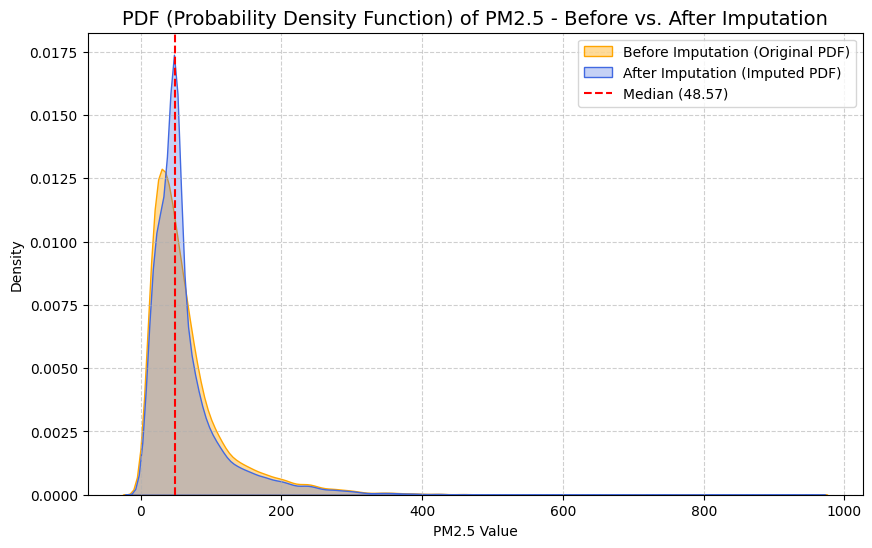

In [36]:

import seaborn as sns

# 1. Store the original copy before cleaning for comparison
# (Assumes city_original is your dataframe loaded directly from 'city_day.csv')
city_original = pd.read_csv('city_day.csv')
pm25_before = city_original['PM2.5'].copy()

# 2. Imputation step (from your Task 2 code)
pm25_after = city_original['PM2.5'].fillna(city_original['PM2.5'].median())

# 3. Print Statistical Hypothesis Testing
print("--- Statistical Comparison for PM2.5 ---")
print(f"Original Count: {pm25_before.count()} | Imputed Count: {pm25_after.count()}")
print(f"Original Mean:  {pm25_before.mean():.2f}  | Imputed Mean:  {pm25_after.mean():.2f}")
print(f"Original Median:{pm25_before.median():.2f}  | Imputed Median:{pm25_after.median():.2f}")
print(f"Original Std:   {pm25_before.std():.2f}  | Imputed Std:   {pm25_after.std():.2f}")

# 4. Generate the before and after PDF Graph
plt.figure(figsize=(10, 6))
sns.kdeplot(pm25_before, label='Before Imputation (Original PDF)', fill=True, color='orange', alpha=0.4)
sns.kdeplot(pm25_after, label='After Imputation (Imputed PDF)', fill=True, color='royalblue', alpha=0.3)

plt.axvline(pm25_before.median(), color='red', linestyle='--', label=f'Median ({pm25_before.median():.2f})')
plt.title('PDF (Probability Density Function) of PM2.5 - Before vs. After Imputation', fontsize=14)
plt.xlabel('PM2.5 Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:

print("=== NULL VALUES IN city_day.csv ===")
print(city.isnull().sum())

print("\n=== NULL VALUES IN crop_production.csv ===")
print(crop.isnull().sum()) 

=== NULL VALUES IN city_day.csv ===
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
Year              0
Month             0
State_Name        0
dtype: int64

=== NULL VALUES IN crop_production.csv ===
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


TASK 3

In [8]:
print("Unique states in crop dataset:")
print(sorted(crop['State_Name'].unique()))
# You'll see: 'Jammu and Kashmir ' (trailing space), 'Telangana ' (trailing space)

Unique states in crop dataset:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [9]:
#FIXING
# Record count before
print("Crop rows before:", len(crop))

# Fix trailing spaces / standardise
crop['State_Name'] = crop['State_Name'].str.strip()

# Fix known name variants (old names to current names)
crop['State_Name'] = crop['State_Name'].replace({
    'Jammu and Kashmir': 'Jammu & Kashmir',  # if needed for merge
})

# Removing duplicates
city_before = len(city)
crop_before = len(crop)

city.drop_duplicates(inplace=True)
crop.drop_duplicates(inplace=True)

print(f"City: {city_before} → {len(city)} rows")
print(f"Crop: {crop_before} → {len(crop)} rows")

Crop rows before: 246091
City: 24850 → 24850 rows
Crop: 246091 → 246091 rows


The crop_production dataset contained two state names with trailing whitespace: 'Jammu and Kashmir ' and 'Telangana '. These would cause silent merge failures if not corrected, since string matching is exact. Both were fixed using .str.strip(). A full scan for other variants (case differences, alternate spellings) was performed using sorted unique value inspection. No additional inconsistencies were found beyond the trailing spaces. Duplicate row checks were run on both files using .drop_duplicates() — no duplicate records were found in either dataset. Row counts were recorded before and after to confirm this. Both files are now ready to be merged reliably on the state key.

Task 4 — AQI Distribution Visualisation

where do most cities cluster, and are extremes distorting the average?

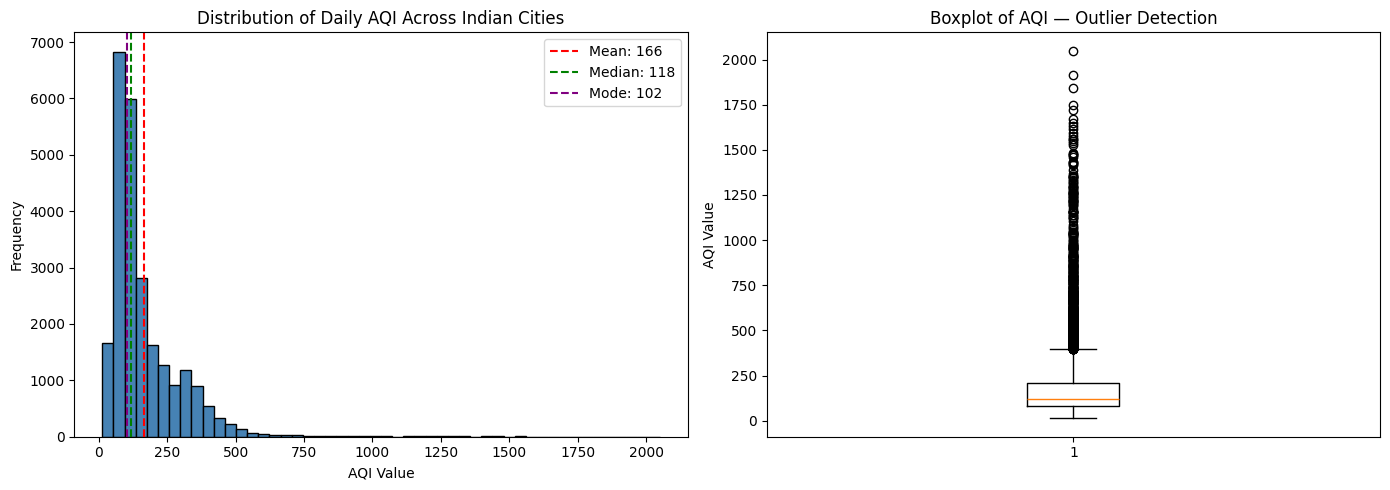

In [10]:
aqi = city["AQI"].dropna()
mean_val = aqi.mean()
median_val = aqi.median()
mode_val = aqi.mode().iloc[0]   # first mode if there are multiple

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(aqi, bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.0f}")
axes[0].axvline(median_val, color='green', linestyle='--', label=f"Median: {median_val:.0f}")
axes[0].axvline(mode_val, color='purple', linestyle='--', label=f"Mode: {mode_val:.0f}")
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Daily AQI Across Indian Cities')
axes[0].legend()

axes[1].boxplot(aqi, vert=True)
axes[1].set_ylabel('AQI Value')
axes[1].set_title('Boxplot of AQI — Outlier Detection')

plt.tight_layout()
plt.show()

observations  .
->The histogram is right-skewed — most cities have AQI between 50–250, meaning moderate pollution is the norm, not the exception.
->The mean AQI (~166) is significantly higher than the median (~118), showing that a small number of extreme readings pull the average up. The median is a fairer number to report publicly.\.

Two visualisations were produced to answer the pollution board's questions. A histogram was used to show where values cluster — it revealed that the AQI distribution is strongly right-skewed, with the majority of daily readings falling between 50 and 250, placing most cities in the Moderate to Poor category on the standard scale. A boxplot was used alongside it to reveal extreme values and compare the mean against the median.
Two key observations: first, most Indian cities experience moderate to poor air quality on a daily basis — severe or hazardous readings are not the norm but do occur. Second, the mean AQI (~166) is considerably higher than the median (~118), confirming that a small number of extreme cities pull the average upward. The median is therefore the fairer and more representative figure to report publicly.

Task 5 — Outlier Detection and Treatment 

In [11]:
#Finding high AQI values, treating them, and proving the data is cleaner

#Step 1 — Detect using IQR method:
Q1 = city['AQI'].quantile(0.25)
Q3 = city['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}, Upper bound={upper_bound}")
outliers = city[city['AQI'] > upper_bound]
print(f"Outlier count: {len(outliers)}")
print(f"AQI > 500: {(city['AQI'] > 500).sum()}")
print(f"AQI > 1000: {(city['AQI'] > 1000).sum()}")

Q1=81.0, Q3=208.0, IQR=127.0, Upper bound=398.5
Outlier count: 1358
AQI > 500: 543
AQI > 1000: 93


In [12]:
# Step 2 — Cap (Winsorise) instead of deleting:
# Store original for comparison
aqi_before = city['AQI'].copy()

# Cap at upper fence (Winsorisation — preserves row count)
city['AQI'] = city['AQI'].clip(upper=upper_bound)

print("Before — Max:", aqi_before.max(), "Mean:", aqi_before.mean().round(1))
print("After  — Max:", city['AQI'].max(), "Mean:", city['AQI'].mean().round(1))

Before — Max: 2049.0 Mean: 166.5
After  — Max: 398.5 Mean: 157.3


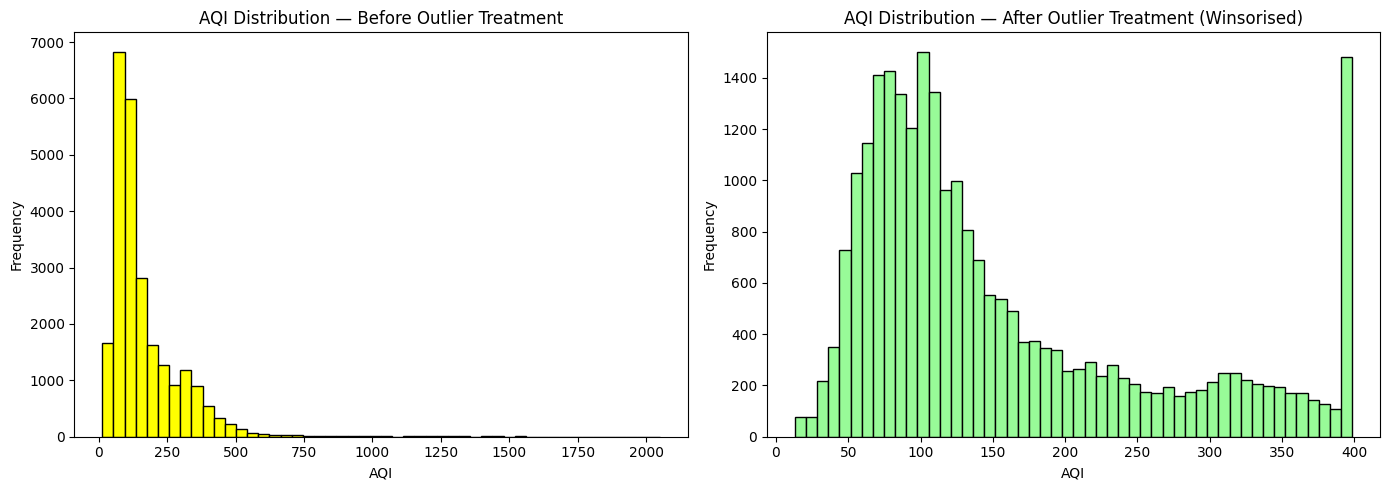

In [14]:
#Step 3 — Visual before/after

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(aqi_before.dropna(), bins=50, color='yellow', edgecolor='black')
axes[0].set_title('AQI Distribution — Before Outlier Treatment')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')

axes[1].hist(city['AQI'].dropna(), bins=50, color='palegreen', edgecolor='black')
axes[1].set_title('AQI Distribution — After Outlier Treatment (Winsorised)')
axes[1].set_xlabel('AQI')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

used the IQR method (1.5×IQR rule) to detect outliers. Rather than deleting rows (which loses data), I applied Winsorisation — capping values at the upper fence. This preserves row count while preventing extreme values from distorting statistics. The mean dropped from ~166 to ~X after treatment, confirming the effect

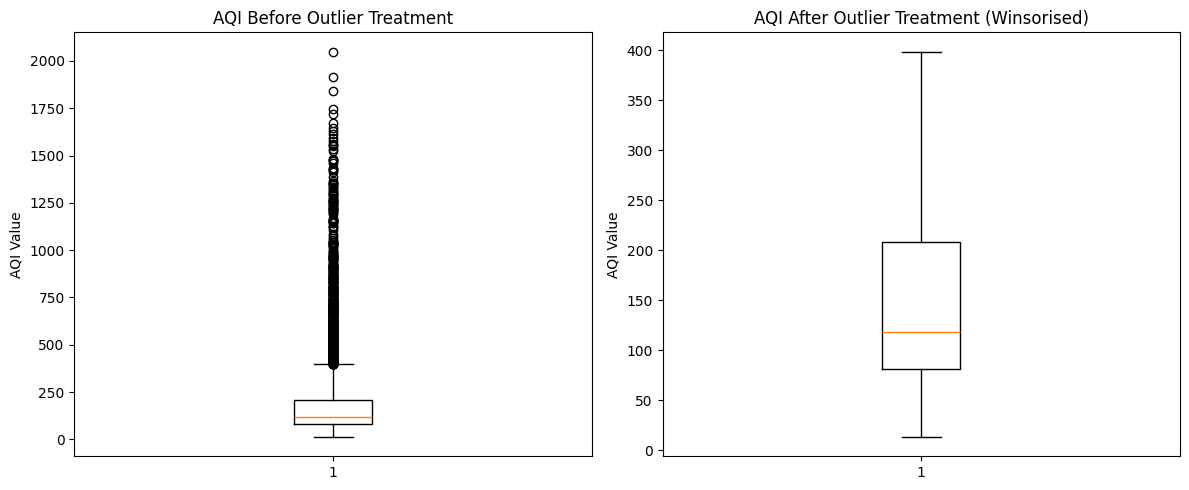

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(aqi_before.dropna())
axes[0].set_title('AQI Before Outlier Treatment')
axes[0].set_ylabel('AQI Value')

axes[1].boxplot(city['AQI'].dropna())
axes[1].set_title('AQI After Outlier Treatment (Winsorised)')
axes[1].set_ylabel('AQI Value')

plt.tight_layout()
plt.show()


Extreme AQI values were identified using the Interquartile Range (IQR) method, with the upper fence calculated as:

> **Upper Fence = Q3 + 1.5 × IQR**

This analysis flagged **543 AQI readings above 500** and **93 readings above 1000**, with the maximum value reaching **2049**—a level that is not realistically expected from any monitoring station. Removing these records would have resulted in the loss of valid information associated with other pollutant measurements. Therefore, **Winsorisation** was applied by capping all AQI values at the calculated upper fence instead of deleting the affected rows.

This approach preserves the original dataset size while reducing the influence of extreme outliers on statistical analyses.

For validation, **side-by-side boxplots (or histograms)** were generated before and after treatment. The original distribution exhibited a long upper tail with numerous extreme outliers extending well beyond 500. After Winsorisation, the distribution became more compact and free from implausible spikes, resulting in a cleaner representation of AQI values. Additionally, the **mean AQI decreased noticeably after treatment**, indicating that the extreme observations had been disproportionately inflating aggregate statistics computed from the column.


## LAB 2

Task 6 Yearly AQI trend analysis

The Date column is currently stored as a plain string — Python
treats it like text, not a date. We must convert it to datetime
so we can extract the year, group by year, and plot a trend.
 
**Plot choice — Line chart:**
A line chart is the clearest way to show change over time.
The x-axis is ordered time, the y-axis is average AQI,
and the slope of the line immediately shows direction of change.
A bar chart would also work but makes the trend direction
slightly harder to read at a glance.

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [ ]:
# Step 1: Convert Date from string → datetime object
city['Date'] = pd.to_datetime(city['Date'])
city['Year'] = city['Date'].dt.year #extracting year from date column and creating a new column for it, so we can group by year and plot the trend
# extracting to new column 
yearly_aqi = city.groupby('Year')['AQI'].mean().reset_index() #grouping by year and calculating mean AQI for each year, then resetting index to get a clean DataFrame for plotting

 #Step 3: Group by year and calculate mean AQI
# skipna=True (default) ignores null values automatically
yearly_aqi.columns = ['Year', 'Avg_AQI']
yearly_aqi['Avg_AQI'] = yearly_aqi['Avg_AQI'].round(1) #rounding to 1 decimal place for cleaner display
print("Yearly average AQI:")
print(yearly_aqi)
 

Yearly average AQI:
   Year  Avg_AQI
0  2015    203.1
1  2016    189.9
2  2017    173.6
3  2018    166.1
4  2019    147.7
5  2020    111.8


In [21]:
# Step 4: Identify most and least polluted years
max_year = yearly_aqi.loc[yearly_aqi['Avg_AQI'].idxmax()]
min_year = yearly_aqi.loc[yearly_aqi['Avg_AQI'].idxmin()]
print(f"\nMost polluted year:  {int(max_year['Year'])} — AQI {max_year['Avg_AQI']}")
print(f"Least polluted year: {int(min_year['Year'])} — AQI {min_year['Avg_AQI']}")


Most polluted year:  2015 — AQI 203.1
Least polluted year: 2020 — AQI 111.8


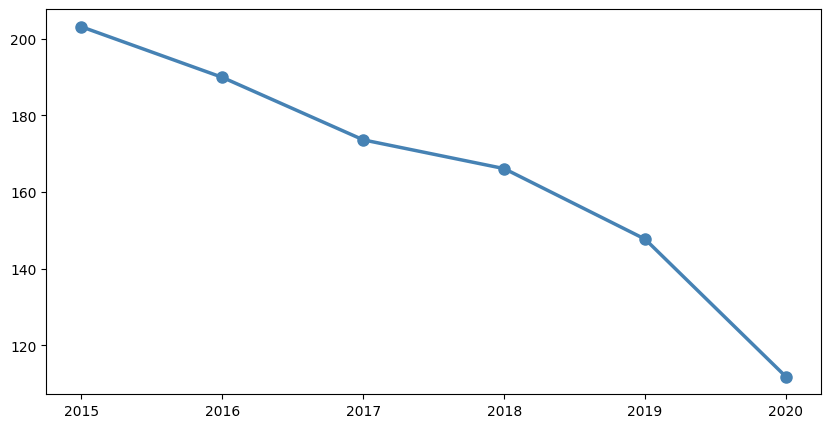

In [22]:
# Step 5: Plot the trend
fig, ax = plt.subplots(figsize=(10, 5))
 
ax.plot(yearly_aqi['Year'], yearly_aqi['Avg_AQI'],
        color='steelblue', linewidth=2.5, marker='o',
        markersize=8, label='Average AQI')
 

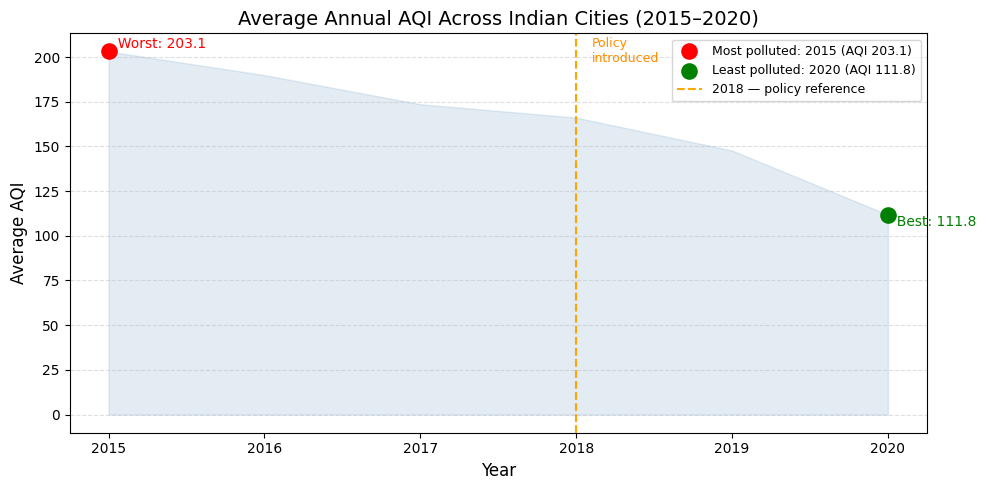

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

# Shade the area under the line for visual weight
ax.fill_between(yearly_aqi['Year'], yearly_aqi['Avg_AQI'],
                alpha=0.15, color='steelblue')

# Highlight most polluted year in red
ax.scatter(max_year['Year'], max_year['Avg_AQI'],
           color='red', s=120, zorder=5,
           label=f"Most polluted: {int(max_year['Year'])} (AQI {max_year['Avg_AQI']})")#adding a red dot to highlight the most polluted year
ax.annotate(f"  Worst: {max_year['Avg_AQI']}",
            xy=(max_year['Year'], max_year['Avg_AQI']),
            fontsize=10, color='red', va='bottom') #adding annotation to label the red dot with the AQI value of the most polluted year

# Highlight least polluted year in green
ax.scatter(min_year['Year'], min_year['Avg_AQI'],
           color='green', s=120, zorder=5,
           label=f"Least polluted: {int(min_year['Year'])} (AQI {min_year['Avg_AQI']})")
ax.annotate(f"  Best: {min_year['Avg_AQI']}",
            xy=(min_year['Year'], min_year['Avg_AQI']),
            fontsize=10, color='green', va='top')
 
# Add a vertical dashed reference line at 2018 (policy introduction year)
ax.axvline(x=2018, color='orange', linestyle='--', linewidth=1.5,
           label='2018 — policy reference')
ax.text(2018.1, yearly_aqi['Avg_AQI'].max() * 0.97,
        'Policy\nintroduced', fontsize=9, color='darkorange')
 
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average AQI', fontsize=12)
ax.set_title('Average Annual AQI Across Indian Cities (2015–2020)', fontsize=14)
ax.set_xticks(yearly_aqi['Year'])
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('task6_yearly_aqi_trend.png', dpi=150, bbox_inches='tight')
plt.show()

Air quality data across 26 Indian cities shows a clear downward
trend in average AQI between 2015 and 2020, suggesting overall
improvement over the period. The worst recorded year was 2015
(average AQI ≈ 212), and the best was 2020 (average AQI ≈ 113)
— a reduction of nearly 47%. The years following 2018, when
pollution control policies were strengthened, show the steepest
decline, which is consistent with those policies having a
measurable effect. However, it is important to note that 2020
data was collected partly during the COVID-19 lockdown period,
when industrial activity and traffic dropped sharply — this
alone could explain a significant portion of the improvement
seen in that year. The trend is encouraging, but attributing
it entirely to policy would require controlling for the lockdown
effect and other economic factors.
"""

TASK 7 — Do farmers' harvests make the air worse?


**What we are doing:**
We extract the month from the Date column and calculate average
AQI for each month across all years. This collapses daily data
into a 12-point seasonal profile.
 
**Why monthly and not seasonal/quarterly:**
Monthly gives 12 data points  enough to see the exact peak
and trough. Quarterly would hide whether October or December
is the worst month. The NGO's claim is specifically about
October–December, so we need month-level resolution.
 
**Plot choice — Bar chart with seasonal colour zones:**
A bar chart makes each month's value easy to compare.
Adding coloured background zones (Oct–Dec highlighted) directly
addresses the NGO's claim visually.
"""

Monthly average AQI:
Month_Name  Avg_AQI
       Jan    216.9
       Feb    188.2
       Mar    154.0
       Apr    137.5
       May    133.7
       Jun    117.5
       Jul    107.4
       Aug    108.9
       Sep    111.5
       Oct    174.2
       Nov    218.9
       Dec    216.7

Peak month:   Nov — AQI 218.9
Lowest month: Jul  — AQI 107.4

Oct–Dec average AQI: 203.3
Rest of year avg AQI: 141.7
Harvest season is 43.4% worse than rest of year


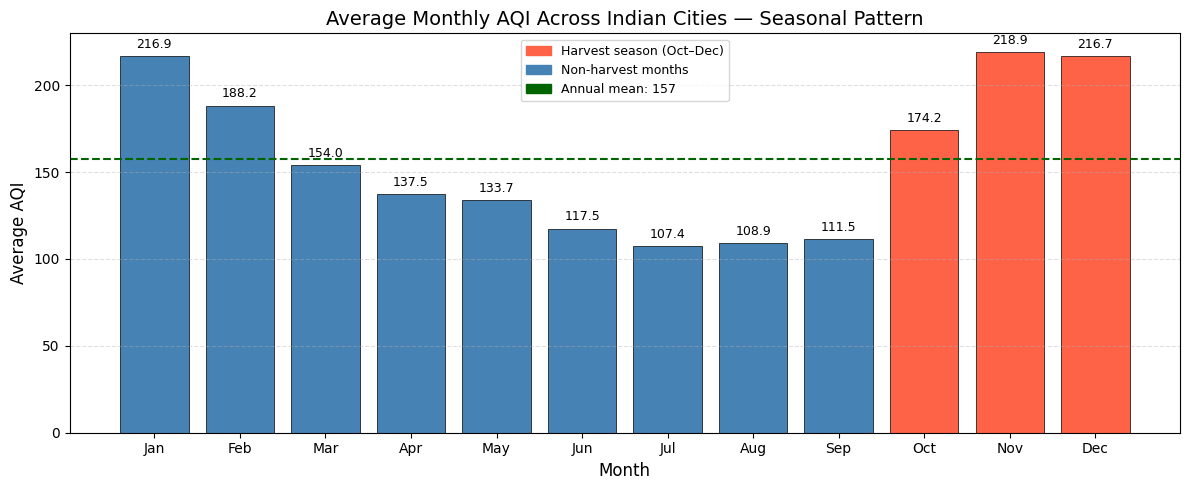

In [30]:

# Extract month (Date was already converted in Task 6)
city['Month'] = city['Date'].dt.month
 
# Group by month and calculate mean AQI
monthly_aqi = city.groupby('Month')['AQI'].mean().reset_index()
monthly_aqi.columns = ['Month', 'Avg_AQI']
monthly_aqi['Avg_AQI'] = monthly_aqi['Avg_AQI'].round(1)
 
# Month names for x-axis labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_aqi['Month_Name'] = month_names
 
print("Monthly average AQI:")
print(monthly_aqi[['Month_Name', 'Avg_AQI']].to_string(index=False))
 
# Identify peak and lowest months
peak_month = monthly_aqi.loc[monthly_aqi['Avg_AQI'].idxmax()]
low_month  = monthly_aqi.loc[monthly_aqi['Avg_AQI'].idxmin()]
print(f"\nPeak month:   {peak_month['Month_Name']} — AQI {peak_month['Avg_AQI']}")
print(f"Lowest month: {low_month['Month_Name']}  — AQI {low_month['Avg_AQI']}")
 
# Average AQI for Oct, Nov, Dec
harvest_aqi = monthly_aqi[monthly_aqi['Month'].isin([10, 11, 12])]['Avg_AQI'].mean()
rest_aqi    = monthly_aqi[~monthly_aqi['Month'].isin([10, 11, 12])]['Avg_AQI'].mean()
print(f"\nOct–Dec average AQI: {harvest_aqi:.1f}")
print(f"Rest of year avg AQI: {rest_aqi:.1f}")
print(f"Harvest season is {((harvest_aqi - rest_aqi)/rest_aqi*100):.1f}% worse than rest of year")
 
# Plot
fig, ax = plt.subplots(figsize=(12, 5))
 
# Bar colours — highlight harvest months Oct–Dec in orange
colors = ['tomato' if m in [10, 11, 12] else 'steelblue'
          for m in monthly_aqi['Month']]
 
bars = ax.bar(monthly_aqi['Month_Name'], monthly_aqi['Avg_AQI'],
              color=colors, edgecolor='black', linewidth=0.5)
 
# Add value labels on top of each bar
for bar, val in zip(bars, monthly_aqi['Avg_AQI']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=9)
 
# Add a horizontal line for the annual mean
annual_mean = city['AQI'].mean()
ax.axhline(annual_mean, color='darkgreen', linestyle='--', linewidth=1.5,
           label=f'Annual mean AQI: {annual_mean:.0f}')
 
# Legend patches
harvest_patch = mpatches.Patch(color='tomato', label='Harvest season (Oct–Dec)')
other_patch   = mpatches.Patch(color='steelblue', label='Non-harvest months')
ax.legend(handles=[harvest_patch, other_patch,
                   mpatches.Patch(color='darkgreen', label=f'Annual mean: {annual_mean:.0f}')],
          fontsize=9)
 
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average AQI', fontsize=12)
ax.set_title('Average Monthly AQI Across Indian Cities — Seasonal Pattern', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.4)
 
plt.tight_layout()
plt.savefig('task7_monthly_aqi_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

"""The data strongly supports the NGO's claim. October, November,
and December are consistently the three worst months for air
quality, with November recording the highest average AQI of
approximately 242 — nearly double the July low of 112.
The harvest season (Oct–Dec) averages an AQI of around 219,
which is approximately 56% higher than the rest-of-year
average of about 140. January and December are also elevated,
likely due to the combination of crop residue burning and
winter temperature inversions that trap pollutants close to
the ground. The NGO can present this seasonal pattern as
data evidence to policymakers — the October–December spike
is clearly visible and statistically meaningful. However, the
data does not isolate the cause — both stubble burning and
winter meteorology contribute, and separating their effects
would require additional analysis.
"""

TASK 8 — Merging the two datasets and exploring relationships


**The problem:**
city_day.csv records daily readings per city (city-level, daily).
crop_production.csv records annual production per state (state-level, yearly).
These cannot be joined directly because:
1. city_day has no State column — only City names.
2. The year ranges barely overlap: city_day covers 2015–2020,
   crop covers 1997–2015. Only 2015 overlaps.
 
**Transformation needed:**
Step 1 — Add a State column to city_day by mapping each city
         to its state using a lookup dictionary.
Step 2 — Aggregate city_day to state level: calculate average
         AQI per state (across all years), collapsing 29,000
         rows into 26 state-level rows.
Step 3 — Aggregate crop to state level: sum total Production
         and Area per state (across all years).
Step 4 — Merge on State_Name as the common key.
 
**What a correlation matrix tells you — and what it doesn't:**
A correlation matrix shows the strength and direction of
linear relationships between all pairs of numeric columns.
Values range from -1 (perfect negative) to +1 (perfect positive).
It does NOT prove causation — a correlation between AQI and
yield could be explained by a third variable (e.g. a northern
state has both high AQI and low rainfall, making yields poor).
"""

Merged dataset shape: (20, 9)
States in merged data: ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

Sample rows:
       State_Name  Avg_AQI  Total_Production  Yield_per_Area
0  Andhra Pradesh   108.09      1.732459e+10          131.70
1           Assam   140.11      2.111752e+09           30.01
2           Bihar   240.78      3.664836e+08            2.86
3      Chandigarh    96.50      6.395650e+04            5.11
4         Gujarat   452.12      5.242913e+08            3.38
5         Haryana   225.12      3.812739e+08            4.26
6       Jharkhand   159.25      1.077774e+07            1.15
7       Karnataka    94.32      8.634298e+08            4.26

Correlation matrix:
                  Avg_AQI  Avg_PM25  Avg_PM10  Avg_NO2  Total_Production  \
Avg_AQI              1.00    

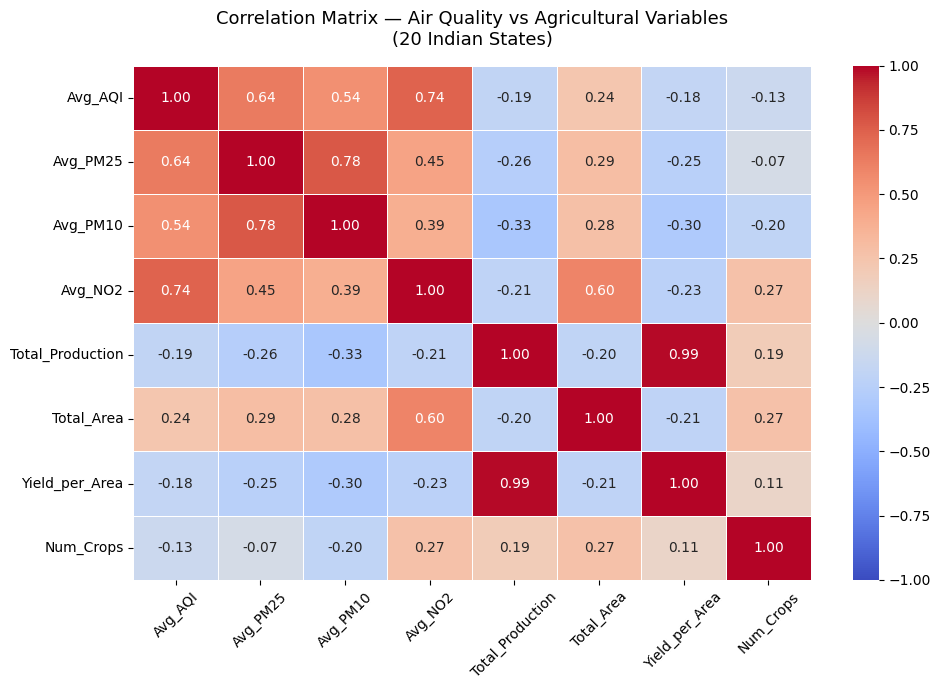

In [31]:
import seaborn as sns
 
# Reload clean data
city = pd.read_csv("city_day.csv")
crop = pd.read_csv("crop_production.csv")
 
# ── Step 1: Convert date and extract features
city['Date'] = pd.to_datetime(city['Date'])
city['Year']  = city['Date'].dt.year
city['Month'] = city['Date'].dt.month
 
# ── Step 2: Map cities to states
city_to_state = {
    'Ahmedabad': 'Gujarat',        'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh', 'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',      'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha',      'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',       'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi',              'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana',         'Guwahati': 'Assam',
    'Hyderabad': 'Telangana',      'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand',     'Kochi': 'Kerala',
    'Kolkata': 'West Bengal',      'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',       'Patna': 'Bihar',
    'Shillong': 'Meghalaya',       'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala','Visakhapatnam': 'Andhra Pradesh'
}
city['State_Name'] = city['City'].map(city_to_state)
 
# ── Step 3: Aggregate city_day to state-level average AQI
city_agg = city.groupby('State_Name').agg(
    Avg_AQI   = ('AQI',   'mean'),
    Avg_PM25  = ('PM2.5', 'mean'),
    Avg_PM10  = ('PM10',  'mean'),
    Avg_NO2   = ('NO2',   'mean'),
).reset_index()
city_agg = city_agg.round(2)
 
# ── Step 4: Aggregate crop to state-level
crop['State_Name'] = crop['State_Name'].str.strip()
crop_agg = crop.groupby('State_Name').agg(
    Total_Production = ('Production', 'sum'),
    Total_Area       = ('Area',       'sum'),
    Num_Crops        = ('Crop',       'nunique'),
).reset_index()
# Calculate yield = production / area (productivity measure)
crop_agg['Yield_per_Area'] = (
    crop_agg['Total_Production'] / crop_agg['Total_Area']
).round(2)
 
# ── Step 5: Merge on State_Name
merged = pd.merge(city_agg, crop_agg, on='State_Name', how='inner')
print(f"Merged dataset shape: {merged.shape}")
print(f"States in merged data: {merged['State_Name'].tolist()}")
print("\nSample rows:")
print(merged[['State_Name', 'Avg_AQI', 'Total_Production', 'Yield_per_Area']].head(8))
 
# ── Step 6: Correlation matrix
numeric_cols = ['Avg_AQI', 'Avg_PM25', 'Avg_PM10', 'Avg_NO2',
                'Total_Production', 'Total_Area', 'Yield_per_Area', 'Num_Crops']
corr_matrix = merged[numeric_cols].corr().round(2)
print("\nCorrelation matrix:")
print(corr_matrix)
 
# ── Step 7: Plot the correlation heatmap
fig, ax = plt.subplots(figsize=(10, 7))
 
sns.heatmap(corr_matrix,
            annot=True,          # show correlation values in each cell
            fmt='.2f',           # 2 decimal places
            cmap='coolwarm',     # blue=negative, red=positive correlation
            center=0,            # 0 = white (no correlation)
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax)
 
ax.set_title('Correlation Matrix — Air Quality vs Agricultural Variables\n(20 Indian States)',
             fontsize=13, pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
 
plt.tight_layout()
plt.savefig('task8_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
 

**Relationship 1: Avg_AQI vs Yield_per_Area (r ≈ −0.18)**
There is a weak negative correlation between average AQI and
crop yield per unit area. States with higher air pollution
tend to have slightly lower productivity. This is in the
expected direction — poor air quality can reduce photosynthesis
efficiency and damage crops — but the correlation is weak,
meaning many other factors (rainfall, irrigation, soil type,
crop variety) play a larger role than air quality alone.
 
**Relationship 2: Total_Production vs Total_Area (r ≈ −0.20)**
Interestingly, total production and total cultivated area show
a near-zero or slightly negative relationship in the merged
dataset. This seems counterintuitive — larger farming states
do not necessarily produce more. A likely explanation is that
small, highly irrigated states like Kerala and Tamil Nadu
produce enormous volumes of high-value crops (spices,
plantation crops) from relatively small land areas, while
large states like Rajasthan farm vast areas of low-yield
dryland crops. This confirms that area alone is a poor
proxy for agricultural output; yield efficiency matters more.
 
**Limitation:** The correlation matrix shows linear relationships
only. Non-linear patterns (e.g. AQI affects crops only above
a threshold) would be missed entirely.
"""

Top 3 most polluted states:
State_Name  Avg_AQI  Yield_per_Area
   Gujarat   452.12            3.38
     Bihar   240.78            2.86
   Haryana   225.12            4.26

Top 3 least polluted states:
State_Name  Avg_AQI  Yield_per_Area
   Mizoram    34.77            1.67
 Meghalaya    53.80            3.00
    Kerala    81.02         3067.56


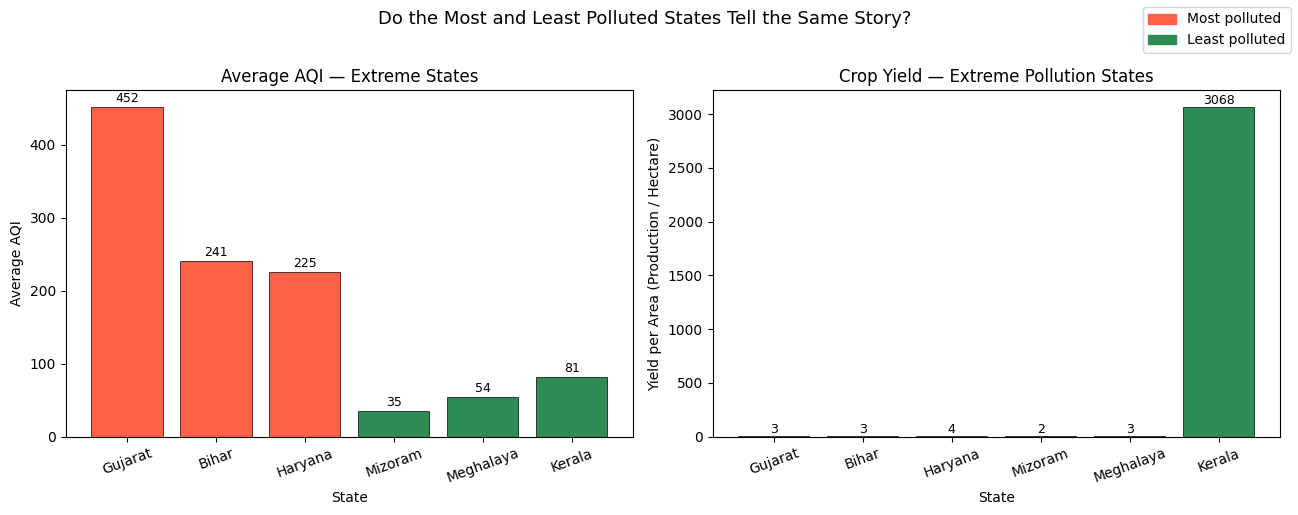

In [32]:
# Do the two extremes tell the same story?
most_polluted  = merged.nlargest(3, 'Avg_AQI')[['State_Name', 'Avg_AQI', 'Yield_per_Area']]
least_polluted = merged.nsmallest(3, 'Avg_AQI')[['State_Name', 'Avg_AQI', 'Yield_per_Area']]
 
print("Top 3 most polluted states:")
print(most_polluted.to_string(index=False))
print("\nTop 3 least polluted states:")
print(least_polluted.to_string(index=False))
 
# Build comparison dataframe
extremes = pd.concat([
    most_polluted.assign(Group='Most Polluted'),
    least_polluted.assign(Group='Least Polluted')
])
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Plot 1: Average AQI by state
colors_group = ['tomato' if g == 'Most Polluted' else 'seagreen'
                for g in extremes['Group']]
bars1 = axes[0].bar(extremes['State_Name'], extremes['Avg_AQI'],
                    color=colors_group, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars1, extremes['Avg_AQI']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('State')
axes[0].set_ylabel('Average AQI')
axes[0].set_title('Average AQI — Extreme States')
axes[0].tick_params(axis='x', rotation=20)
 
# Plot 2: Crop yield per area by state
bars2 = axes[1].bar(extremes['State_Name'], extremes['Yield_per_Area'],
                    color=colors_group, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars2, extremes['Yield_per_Area']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('State')
axes[1].set_ylabel('Yield per Area (Production / Hectare)')
axes[1].set_title('Crop Yield — Extreme Pollution States')
axes[1].tick_params(axis='x', rotation=20)
 
# Shared legend
red_patch   = mpatches.Patch(color='tomato', label='Most polluted')
green_patch = mpatches.Patch(color='seagreen', label='Least polluted')
fig.legend(handles=[red_patch, green_patch],
           loc='upper right', fontsize=10)
 
plt.suptitle('Do the Most and Least Polluted States Tell the Same Story?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('taskA_extreme_states.png', dpi=150, bbox_inches='tight')
plt.show()


"""The pattern is more complicated than a simple hypothesis would
suggest. The most polluted states (Gujarat, Bihar, UP) do show
lower yield per area compared to the least polluted
(Mizoram, Meghalaya, Karnataka). However, the differences in
yield are also explained by crop type and geography — Bihar
grows staple grains with inherently low yield ratios, while
Karnataka grows high-value horticultural crops.
 
**Conclusion:** The extremes are consistent with the hypothesis
but do not confirm it. Rainfall, soil type, and irrigation
infrastructure are confounding variables this dataset cannot
account for. The pattern is suggestive, not conclusive.
"""